In [1]:
import sys
sys.path.append('../')

In [2]:
from moabb.paradigms import MotorImagery
from moabb.datasets import *

dataset = AlexMI()
sfreq=250
paradigm = MotorImagery(resample=sfreq)

Choosing from all possible events


In [3]:
from sklearn.preprocessing import FunctionTransformer

from classification_mi import stf_transform 

cache_config = dict(
    use=True,
    save_raw=False,
    save_epochs=False,
    save_array=True,
    overwrite_raw=False,
    overwrite_epochs=False,
    overwrite_array=False,
)

X, y, meta = paradigm.get_data(
     dataset=dataset, 
     subjects=[1],
     return_epochs=False,
     postprocess_pipeline = FunctionTransformer(stf_transform),
     cache_config=cache_config,

)



In [4]:
import tensorly as tl
from bttda.classification import ZScore

X = tl.tensor(X)
X = ZScore().fit_transform(X)

In [5]:
from bttda.hoda import HODA

hoda = HODA(
        shrinkage='lw',
        obj='tr',
        toeplitz=None,
        extra_train_info=True,
        verbose=True,
        theta=0.2,
)


In [6]:
import pandas as pd

hoda.fit_backward(X,y)
df = pd.DataFrame(hoda.train_info_['backward'])

Backward HODA model rank=(1, 2, 2):  81%|████████▏ | 208/256 [00:08<00:01, 25.66it/s]


In [7]:
df

,iteration,mode,flip,update,shrinkage,objective,F_tr,F_rt
0,1,1,1,7.986353e-01,0.026315,123462.869028,0.071999,0.015651
1,1,2,2,1.385001e+00,0.104671,119735.268892,0.192504,0.038552
2,1,3,3,1.386799e+00,0.178829,77313.084622,0.396648,0.080094
3,2,1,4,5.530239e-01,0.025199,101383.106319,0.462290,0.095630
4,2,2,5,1.273127e+00,0.145542,70317.451566,0.750530,0.125900
...,...,...,...,...,...,...,...,...
622,208,2,623,5.947826e-09,0.292154,72466.952377,3.376202,0.251093
623,208,3,624,1.066765e-08,0.275936,39585.935675,3.376202,0.251093
624,209,1,625,8.409341e-09,0.101754,43980.771157,3.376202,0.251093
625,209,2,626,5.525578e-09,0.292154,72466.952390,3.376202,0.251093


In [8]:
import plotly.express as px

if hoda.extra_train_info:
    fig = px.line(df, x='flip', y='F_tr')
    fig.show()

In [9]:
if hoda.extra_train_info:
    fig = px.line(df, x='flip', y='F_rt')
    fig.show()

In [10]:
px.line(df, x='flip', y='update', log_y=True, color='mode')


In [11]:
hoda.fit_forward(X,y)
df = pd.DataFrame(hoda.train_info_['forward'])
df

Forward model :  13%|█▎        | 34/255 [00:00<00:03, 63.81it/s]


,iteration,mode,flip,update,lambda_,mse,nmse
0,1,1,1,1.635506e+00,0.0,0.997169,0.997169
1,1,2,2,1.413062e+00,0.0,0.995679,0.995679
2,1,3,3,2.460993e+00,0.0,0.992004,0.992004
3,2,1,4,2.259801e-01,0.0,0.991596,0.991596
4,2,2,5,6.709056e-01,0.0,0.990483,0.990483
...,...,...,...,...,...,...,...
100,34,2,101,1.542387e-08,0.0,0.989924,0.989924
101,34,3,102,1.058475e-08,0.0,0.989924,0.989924
102,35,1,103,1.226966e-09,0.0,0.989924,0.989924
103,35,2,104,9.388539e-09,0.0,0.989924,0.989924


In [12]:
if hoda.extra_train_info:
    px.line(df, x='flip', y='mse', log_y=True)

In [13]:
px.line(df, x='flip', y='update', log_y=True, color='mode')

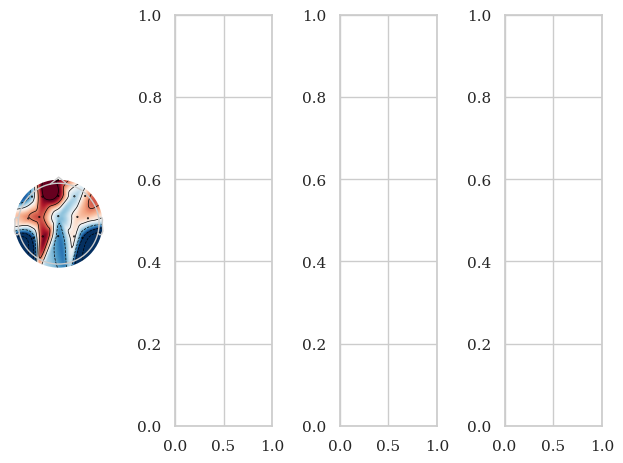

In [14]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl
from mne import create_info

col_wrap = 4

ch_names = ['Fpz', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T7', 'C3', 'Cz', 'C4', 'T8', 'P7', 'P3', 'Pz', 'P4', 'P8']
info = create_info(ch_names,1, ch_types='eeg')
info.set_montage('standard_1020')
n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
vmax = float(tl.max(tl.abs(hoda.weights_[0])))
for i in range(hoda.rank_[0]):
    w = tl.to_numpy(hoda.weights_[0][:,i])
    plot_topomap(w, info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

In [15]:
from mne.viz import plot_topomap

df = pd.DataFrame(tl.to_numpy(hoda.weights_[1]))
df['frequency'] = np.geomspace(8,32,16)
df = df.melt(id_vars=['frequency'], var_name='rank', value_name='weight')
px.line(df, x='frequency', y='weight', facet_col='rank', facet_col_wrap=4, log_x=True)

In [16]:
df = pd.DataFrame(tl.to_numpy(hoda.weights_[2]))
df['time bin'] = np.arange(X.shape[-1])
df = df.melt(id_vars=['time bin'], var_name='rank', value_name='weight')
px.line(df, x='time bin', y='weight', facet_col='rank', facet_col_wrap=4)

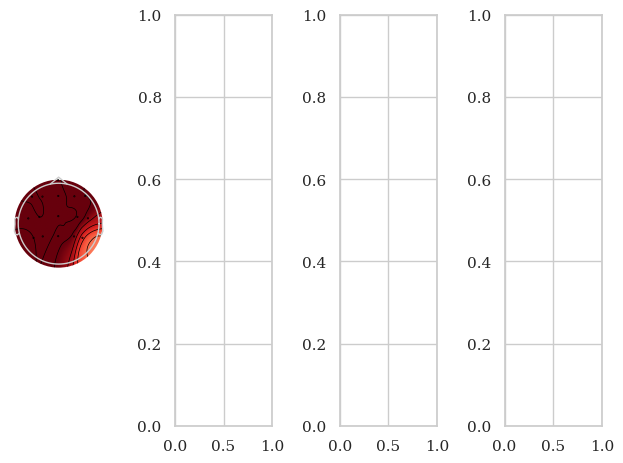

In [17]:
fig, axs = plt.subplots(n_row, n_col, layout='tight')
vmax = float(tl.max(tl.abs(hoda.weights_[0])))
for i in range(hoda.rank_[0]):
    ap = tl.to_numpy(hoda.aps_[0][:,i])
    plot_topomap(ap, info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

In [18]:
df = pd.DataFrame(tl.to_numpy(hoda.aps_[1]))
df['frequency'] = np.geomspace(8,32,16)
df = df.melt(id_vars=['frequency'], var_name='rank', value_name='weight')
px.line(df, x='frequency', y='weight', facet_col='rank', facet_col_wrap=4, log_x=True)

In [19]:
df = pd.DataFrame(tl.to_numpy(hoda.aps_[2]))
df['time bin'] = np.arange(X.shape[-1])
df = df.melt(id_vars=['time bin'], var_name='rank', value_name='weight')
px.line(df, x='time bin', y='weight', facet_col='rank', facet_col_wrap=4)

In [20]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from bttda.classification import SelectFCutoff

Xt = hoda.transform(X)
xt = tl.to_numpy(tl.unfold(Xt,0))

select = SelectFCutoff()
xts = select.fit_transform(xt,y)

df = pd.DataFrame({
    'feature': np.arange(xt.shape[-1]),
    'F': select.scores_,
    'significant': select.scores_>1,
})
df

,feature,F,significant
0,0,115.156358,True
1,1,26.125697,True
2,2,1.943965,True
3,3,0.298720,False


In [21]:
from sklearn.decomposition import PCA

x_viz = PCA(n_components=2, whiten=True).fit_transform(xts)
fig = px.scatter(x=x_viz[:,0], y=x_viz[:,1], color=y)
fig.update_yaxes(
    scaleanchor="x",
    scaleratio=1,
  )

In [22]:
from bttda.hoda import f_multiway

print(f"trace-ratio: {f_multiway(xts,y, method='tr')}")
print(f"ratio-trace: {f_multiway(xts,y, method='rt')}")

trace-ratio: 3.4966417415113837
ratio-trace: 0.24610171793993638
